
          COMPLETE SHOR'S ALGORITHM ANALYSIS
               N=15 and N=21 - ALL BASES

██████████████████████████████████████████████████████████████████████
█                                                                    █
█                    ANALYZING N=15                                  █
█                                                                    █
██████████████████████████████████████████████████████████████████████

COMPLETE ANALYSIS FOR N=15

Found 7 valid bases: [2, 4, 7, 8, 11, 13, 14]

PRE-ANALYSIS: BASE VALIDITY CHECK

a= 2: ✓ GOOD
  Period r=4, Period r=4 is even and will yield factors
  Expected factors: [3, 5]

a= 4: ✓ GOOD
  Period r=2, Period r=2 is even and will yield factors
  Expected factors: [3, 5]

a= 7: ✓ GOOD
  Period r=4, Period r=4 is even and will yield factors
  Expected factors: [3, 5]

a= 8: ✓ GOOD
  Period r=4, Period r=4 is even and will yield factors
  Expected factors: [3, 5]

a=11: ✓ GOOD
  Period r=2, Period r=2 is even and will yie

C:\Users\User\AppData\Local\Temp\ipykernel_10464\2636158722.py:216: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_inverse = QFT(n_count, inverse=True)



📊 CIRCUIT: 12 qubits, depth=157, gates=312
🔬 Simulating (2048 shots)... ✓

📈 RESULTS:
  Success Rate: 8.54%
  Factors Found: [3, 5]
  ✓ Factorization: 15 = 3 × 5

[2/7] Processing base a=4...

RUNNING: N=15, a=4

📋 BASE VALIDITY CHECK:
  Valid: True
  Reason: Period r=2 is even and will yield factors
  Expected Period: r = 2
  Likely Success: True
  Expected Factors: [3, 5]

📊 CIRCUIT: 12 qubits, depth=158, gates=315
🔬 Simulating (2048 shots)... 

C:\Users\User\AppData\Local\Temp\ipykernel_10464\2636158722.py:216: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_inverse = QFT(n_count, inverse=True)


✓

📈 RESULTS:
  Success Rate: 16.16%
  Factors Found: [3, 5]
  ✓ Factorization: 15 = 3 × 5

[3/7] Processing base a=7...

RUNNING: N=15, a=7

📋 BASE VALIDITY CHECK:
  Valid: True
  Reason: Period r=4 is even and will yield factors
  Expected Period: r = 4
  Likely Success: True
  Expected Factors: [3, 5]

📊 CIRCUIT: 12 qubits, depth=175, gates=330
🔬 Simulating (2048 shots)... ✓

📈 RESULTS:
  Success Rate: 9.96%
  Factors Found: [3, 5]
  ✓ Factorization: 15 = 3 × 5

[4/7] Processing base a=8...

RUNNING: N=15, a=8

📋 BASE VALIDITY CHECK:
  Valid: True
  Reason: Period r=4 is even and will yield factors
  Expected Period: r = 4
  Likely Success: True
  Expected Factors: [3, 5]

📊 CIRCUIT: 12 qubits, depth=151, gates=306
🔬 Simulating (2048 shots)... ✓

📈 RESULTS:
  Success Rate: 8.11%
  Factors Found: [3, 5]
  ✓ Factorization: 15 = 3 × 5

[5/7] Processing base a=11...

RUNNING: N=15, a=11

📋 BASE VALIDITY CHECK:
  Valid: True
  Reason: Period r=2 is even and will yield factors
  Expected 

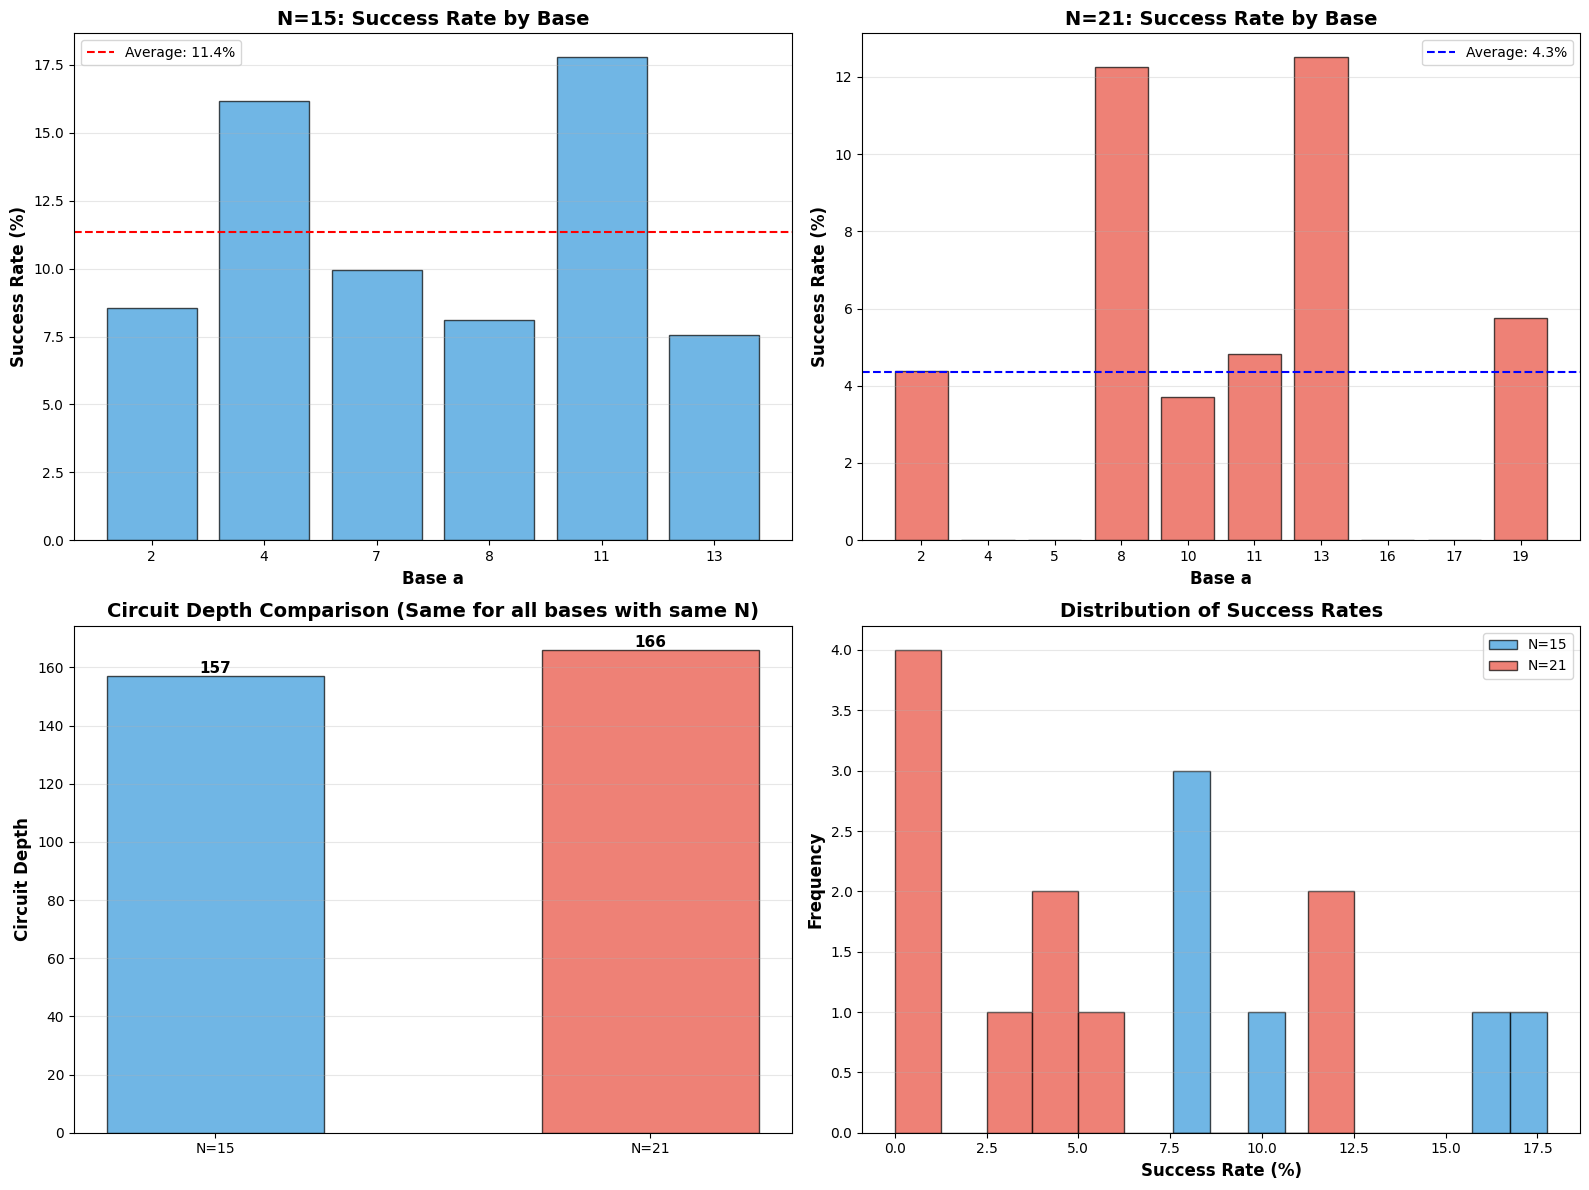

In [1]:
"""
Generalized Shor's Algorithm Implementation
Complete Analysis for N=15 and N=21 with All Valid Bases
Quantum Computing Research - Comparative Analysis
"""

import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from collections import Counter
import math
import sys

# Qiskit 1.x imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit import transpile

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def gcd(a, b):
    """Compute greatest common divisor using Euclidean algorithm."""
    while b:
        a, b = b, a % b
    return a

def find_valid_bases(N):
    """
    Find all valid bases 'a' for Shor's algorithm for a given N.
    
    Args:
        N: Number to factor
    
    Returns:
        List of valid bases
    """
    valid_bases = []
    for a in range(2, N):
        if gcd(a, N) == 1:
            valid_bases.append(a)
    return valid_bases

def find_period_classical(a, N):
    """
    Classically find the period r where a^r ≡ 1 (mod N).
    Used for verification and comparison.
    
    Args:
        a: Base
        N: Modulus
    
    Returns:
        Period r
    """
    r = 1
    current = a % N
    while current != 1:
        current = (current * a) % N
        r += 1
        if r > N:  # Safety check
            return None
    return r

def check_base_validity(a, N):
    """
    Check if base 'a' is valid and potentially successful.
    
    Args:
        a: Base to check
        N: Number to factor
    
    Returns:
        Dictionary with validity information
    """
    result = {
        'a': a,
        'N': N,
        'valid': False,
        'reason': '',
        'expected_period': None,
        'period_is_even': None,
        'likely_success': False
    }
    
    # Check if coprime
    g = gcd(a, N)
    if g != 1:
        result['reason'] = f'gcd({a}, {N}) = {g} ≠ 1 (not coprime, but found factor!)'
        result['trivial_factor'] = g
        return result
    
    # Check trivial cases
    if a == 1:
        result['reason'] = 'a = 1 is trivial'
        return result
    
    if a == N - 1:
        result['reason'] = 'a = N-1 gives period r=2 but trivial factors'
        return result
    
    # Find period classically
    r = find_period_classical(a, N)
    if r is None:
        result['reason'] = 'Could not determine period'
        return result
    
    result['valid'] = True
    result['expected_period'] = r
    result['period_is_even'] = (r % 2 == 0)
    
    if r % 2 != 0:
        result['reason'] = f'Period r={r} is odd (will likely fail)'
        result['likely_success'] = False
    else:
        # Check if we'll get non-trivial factors
        factor1 = gcd(pow(a, r//2, N) - 1, N)
        factor2 = gcd(pow(a, r//2, N) + 1, N)
        
        if (factor1 > 1 and factor1 < N) or (factor2 > 1 and factor2 < N):
            result['reason'] = f'Period r={r} is even and will yield factors'
            result['likely_success'] = True
            result['expected_factors'] = sorted(list(set([f for f in [factor1, factor2, N//factor1, N//factor2] 
                                                if f > 1 and f < N])))
        else:
            result['reason'] = f'Period r={r} is even but gives trivial factors'
            result['likely_success'] = False
    
    return result

# ============================================================================
# GENERIC MODULAR MULTIPLIER CIRCUIT
# ============================================================================

def controlled_modular_multiplier(circuit, control_qubit, target_qubits, multiplier, N):
    """
    Implements controlled modular multiplication: |x⟩ → |ax mod N⟩
    Generic implementation using controlled operations for fair resource comparison.
    """
    n_target = len(target_qubits)
    
    for i in range(n_target):
        if multiplier & (1 << i):
            for j in range(i, n_target):
                circuit.cx(control_qubit, target_qubits[j])
                circuit.rz(np.pi / (2 ** (j - i + 1)), target_qubits[j])
                circuit.cx(control_qubit, target_qubits[j])

# ============================================================================
# SHOR'S ALGORITHM CIRCUIT CONSTRUCTION
# ============================================================================

def build_shors_circuit(N, a, verbose=True):
    """
    Build complete Shor's algorithm circuit for factoring N with base a.
    
    Args:
        N: Number to factor
        a: Coprime base for modular exponentiation
        verbose: Print construction details
    
    Returns:
        QuantumCircuit, n_count, n_target
    """
    # Determine number of qubits needed
    n_target = int(np.ceil(np.log2(N)))
    n_count = 2 * n_target
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"CIRCUIT CONSTRUCTION: N={N}, a={a}")
        print(f"{'='*70}")
        print(f"Target qubits needed: {n_target} (to represent numbers up to {N})")
        print(f"Counting qubits needed: {n_count} (for phase estimation precision)")
        print(f"Total qubits: {n_count + n_target}")
    
    # Create quantum and classical registers
    count_reg = QuantumRegister(n_count, 'count')
    target_reg = QuantumRegister(n_target, 'target')
    meas_reg = ClassicalRegister(n_count, 'meas')
    
    qc = QuantumCircuit(count_reg, target_reg, meas_reg)
    
    # Step 1: Initialize counting register in uniform superposition
    if verbose:
        print("\nStep 1: Creating superposition in counting register...")
    for i in range(n_count):
        qc.h(count_reg[i])
    
    # Step 2: Initialize target register to |1⟩
    if verbose:
        print("Step 2: Initializing target register to |1⟩...")
    qc.x(target_reg[0])
    
    # Step 3: Apply controlled modular exponentiation
    if verbose:
        print("Step 3: Applying controlled modular exponentiation...")
    for j in range(n_count):
        power = pow(a, 2**j, N)
        if verbose:
            print(f"  Control qubit {j}: U^(2^{j}) where a^(2^{j}) mod {N} = {power}")
        
        controlled_modular_multiplier(qc, count_reg[j], 
                                     list(range(n_count, n_count + n_target)), 
                                     power, N)
        
        for k in range(n_target - 1):
            qc.cx(target_reg[k], target_reg[k + 1])
            qc.cx(count_reg[j], target_reg[k])
    
    # Step 4: Apply inverse QFT
    if verbose:
        print("Step 4: Applying inverse Quantum Fourier Transform...")
    qft_inverse = QFT(n_count, inverse=True)
    qc.append(qft_inverse, count_reg)
    
    # Step 5: Measure
    if verbose:
        print("Step 5: Adding measurement operations...")
    qc.measure(count_reg, meas_reg)
    
    if verbose:
        print(f"{'='*70}\n")
    
    return qc, n_count, n_target

# ============================================================================
# ANALYSIS FUNCTIONS
# ============================================================================

def analyze_circuit(qc, N, a, basis_gates=['u', 'cx']):
    """Analyze circuit resources with NO optimization."""
    transpiled_qc = transpile(qc, basis_gates=basis_gates, optimization_level=0)
    
    metrics = {
        'N': N,
        'a': a,
        'total_qubits': qc.num_qubits,
        'count_qubits': len([reg for reg in qc.qregs if reg.name == 'count'][0]),
        'target_qubits': len([reg for reg in qc.qregs if reg.name == 'target'][0]),
        'depth': transpiled_qc.depth(),
        'gate_counts': dict(transpiled_qc.count_ops()),
        'circuit': qc,
        'transpiled_circuit': transpiled_qc
    }
    
    return metrics

def process_measurement_results(counts, N, a, n_count):
    """Process measurement results with detailed error tracking."""
    results = {
        'successes': [],
        'failures': [],
        'factors_found': set(),
        'error_categories': {
            'trivial_measurement': [],
            'odd_period': [],
            'wrong_period': [],
            'trivial_factors': [],
            'period_not_found': []
        },
        'total_shots': sum(counts.values()),
        'unique_outcomes': len(counts)
    }
    
    for bitstring, count in counts.items():
        measured_int = int(bitstring, 2)
        phase = measured_int / (2 ** n_count)
        
        if measured_int == 0:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'reason': 'Measured 0 (trivial result)'
            }
            results['failures'].append(error_data)
            results['error_categories']['trivial_measurement'].append(error_data)
            continue
        
        try:
            frac = Fraction(phase).limit_denominator(N)
            r = frac.denominator
        except:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'reason': 'Could not determine period from phase'
            }
            results['failures'].append(error_data)
            results['error_categories']['period_not_found'].append(error_data)
            continue
        
        if r % 2 != 0:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'period': r,
                'reason': f'Period r={r} is odd (need even period)'
            }
            results['failures'].append(error_data)
            results['error_categories']['odd_period'].append(error_data)
            continue
        
        if pow(a, r, N) != 1:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'period': r,
                'verification': pow(a, r, N),
                'reason': f'a^r mod N = {pow(a, r, N)} ≠ 1 (invalid period)'
            }
            results['failures'].append(error_data)
            results['error_categories']['wrong_period'].append(error_data)
            continue
        
        factor1 = gcd(pow(a, r//2, N) - 1, N)
        factor2 = gcd(pow(a, r//2, N) + 1, N)
        
        success = False
        
        if factor1 > 1 and factor1 < N:
            results['factors_found'].add(factor1)
            results['factors_found'].add(N // factor1)
            results['successes'].append({
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'period': r,
                'factor': factor1,
                'complementary_factor': N // factor1
            })
            success = True
        
        if factor2 > 1 and factor2 < N and factor2 != factor1:
            results['factors_found'].add(factor2)
            results['factors_found'].add(N // factor2)
            if not success:
                results['successes'].append({
                    'bitstring': bitstring,
                    'count': count,
                    'measured_int': measured_int,
                    'phase': phase,
                    'period': r,
                    'factor': factor2,
                    'complementary_factor': N // factor2
                })
            success = True
        
        if not success:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'period': r,
                'factor1': factor1,
                'factor2': factor2,
                'reason': f'Factors are trivial: gcd(a^(r/2)±1, N) = {factor1}, {factor2}'
            }
            results['failures'].append(error_data)
            results['error_categories']['trivial_factors'].append(error_data)
    
    return results

def calculate_error_statistics(results):
    """Calculate comprehensive error statistics."""
    total_shots = results['total_shots']
    
    error_shot_counts = {}
    for category, errors in results['error_categories'].items():
        error_shot_counts[category] = sum(e['count'] for e in errors)
    
    success_shots = sum(s['count'] for s in results['successes'])
    failure_shots = sum(f['count'] for f in results['failures'])
    
    statistics = {
        'total_shots': total_shots,
        'success_shots': success_shots,
        'failure_shots': failure_shots,
        'success_rate': (success_shots / total_shots * 100) if total_shots > 0 else 0,
        'failure_rate': (failure_shots / total_shots * 100) if total_shots > 0 else 0,
        'unique_successful_outcomes': len(results['successes']),
        'unique_failed_outcomes': len(results['failures']),
        'error_breakdown': {}
    }
    
    for category, shot_count in error_shot_counts.items():
        statistics['error_breakdown'][category] = {
            'shots': shot_count,
            'percentage': (shot_count / total_shots * 100) if total_shots > 0 else 0,
            'unique_outcomes': len(results['error_categories'][category])
        }
    
    return statistics

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_shors_for_base(N, a, shots=2048):
    """
    Run Shor's algorithm for a specific N and a.
    
    Args:
        N: Number to factor
        a: Base to use
        shots: Number of measurement shots
    
    Returns:
        Dictionary with all results
    """
    print(f"\n{'='*70}")
    print(f"RUNNING: N={N}, a={a}")
    print(f"{'='*70}")
    
    # Check validity
    validity = check_base_validity(a, N)
    
    print(f"\n📋 BASE VALIDITY CHECK:")
    print(f"  Valid: {validity['valid']}")
    print(f"  Reason: {validity['reason']}")
    if validity.get('expected_period'):
        print(f"  Expected Period: r = {validity['expected_period']}")
        print(f"  Likely Success: {validity['likely_success']}")
        if validity.get('expected_factors'):
            print(f"  Expected Factors: {validity['expected_factors']}")
    
    if not validity['valid']:
        print(f"\n⚠ Skipping this base...")
        if 'trivial_factor' in validity:
            print(f"  Found trivial factor: {validity['trivial_factor']}")
        return None
    
    # Build circuit
    qc, n_count, n_target = build_shors_circuit(N, a, verbose=False)
    
    # Analyze circuit
    metrics = analyze_circuit(qc, N, a)
    print(f"\n📊 CIRCUIT: {metrics['total_qubits']} qubits, depth={metrics['depth']}, gates={sum(metrics['gate_counts'].values())}")
    
    # Simulate
    print(f"🔬 Simulating ({shots} shots)...", end=' ')
    simulator = AerSimulator()
    transpiled_qc = transpile(qc, simulator, optimization_level=0)
    job = simulator.run(transpiled_qc, shots=shots)
    result = job.result()
    counts = result.get_counts()
    print("✓")
    
    # Process results
    analysis = process_measurement_results(counts, N, a, n_count)
    stats = calculate_error_statistics(analysis)
    
    print(f"\n📈 RESULTS:")
    print(f"  Success Rate: {stats['success_rate']:.2f}%")
    print(f"  Factors Found: {sorted(analysis['factors_found'])}")
    
    if analysis['factors_found']:
        factors = sorted(analysis['factors_found'])
        print(f"  ✓ Factorization: {N} = {factors[0]} × {factors[1]}")
    
    return {
        'N': N,
        'a': a,
        'validity': validity,
        'metrics': metrics,
        'counts': counts,
        'analysis': analysis,
        'statistics': stats
    }

def compare_all_bases_for_N(N, shots=2048):
    """
    Run comprehensive analysis for ALL valid bases for a given N.
    
    Args:
        N: Number to factor
        shots: Number of shots per run
    
    Returns:
        List of results for all bases
    """
    print("\n" + "="*70)
    print(f"COMPLETE ANALYSIS FOR N={N}")
    print("="*70)
    
    # Find all valid bases
    valid_bases = find_valid_bases(N)
    print(f"\nFound {len(valid_bases)} valid bases: {valid_bases}")
    
    # First, check which bases will likely succeed
    print(f"\n{'='*70}")
    print("PRE-ANALYSIS: BASE VALIDITY CHECK")
    print(f"{'='*70}")
    
    good_bases = []
    poor_bases = []
    
    for a in valid_bases:
        validity = check_base_validity(a, N)
        if validity['likely_success']:
            good_bases.append(a)
            status = "✓ GOOD"
        else:
            poor_bases.append(a)
            status = "✗ POOR"
        
        print(f"\na={a:2d}: {status}")
        print(f"  Period r={validity.get('expected_period', 'N/A')}, {validity['reason']}")
        if validity.get('expected_factors'):
            print(f"  Expected factors: {validity['expected_factors']}")
    
    print(f"\n{'='*70}")
    print(f"SUMMARY: {len(good_bases)} likely successful, {len(poor_bases)} likely unsuccessful")
    print(f"  Good bases: {good_bases}")
    print(f"  Poor bases: {poor_bases}")
    print(f"{'='*70}")
    
    # Now run quantum simulation for ALL bases
    print(f"\n{'='*70}")
    print("QUANTUM SIMULATION FOR ALL BASES")
    print(f"{'='*70}")
    
    results_list = []
    
    for i, a in enumerate(valid_bases, 1):
        print(f"\n[{i}/{len(valid_bases)}] Processing base a={a}...")
        result = run_shors_for_base(N, a, shots)
        if result is not None:
            results_list.append(result)
    
    return results_list

def print_comprehensive_summary(results_n15, results_n21):
    """Print comprehensive comparison summary."""
    print("\n" + "="*70)
    print(" "*20 + "COMPREHENSIVE SUMMARY")
    print("="*70)
    
    # Summary for N=15
    print(f"\n{'='*70}")
    print("N=15 RESULTS")
    print(f"{'='*70}")
    print(f"\n{'Base a':<8} {'Period r':<10} {'Success':<10} {'Success Rate':<15} {'Factors':<20}")
    print("-" * 70)
    
    for result in results_n15:
        a = result['a']
        period = result['validity'].get('expected_period', 'N/A')
        likely = "Yes" if result['validity']['likely_success'] else "No"
        success_rate = f"{result['statistics']['success_rate']:.2f}%"
        factors = str(sorted(result['analysis']['factors_found'])) if result['analysis']['factors_found'] else "None"
        
        print(f"{a:<8} {period:<10} {likely:<10} {success_rate:<15} {factors:<20}")
    
    # Summary for N=21
    print(f"\n{'='*70}")
    print("N=21 RESULTS")
    print(f"{'='*70}")
    print(f"\n{'Base a':<8} {'Period r':<10} {'Success':<10} {'Success Rate':<15} {'Factors':<20}")
    print("-" * 70)
    
    for result in results_n21:
        a = result['a']
        period = result['validity'].get('expected_period', 'N/A')
        likely = "Yes" if result['validity']['likely_success'] else "No"
        success_rate = f"{result['statistics']['success_rate']:.2f}%"
        factors = str(sorted(result['analysis']['factors_found'])) if result['analysis']['factors_found'] else "None"
        
        print(f"{a:<8} {period:<10} {likely:<10} {success_rate:<15} {factors:<20}")
    
    # Statistical comparison
    print(f"\n{'='*70}")
    print("STATISTICAL COMPARISON")
    print(f"{'='*70}")
    
    # N=15 statistics
    n15_success_rates = [r['statistics']['success_rate'] for r in results_n15]
    n15_avg = np.mean(n15_success_rates)
    n15_max = np.max(n15_success_rates)
    n15_min = np.min(n15_success_rates)
    
    # N=21 statistics
    n21_success_rates = [r['statistics']['success_rate'] for r in results_n21]
    n21_avg = np.mean(n21_success_rates)
    n21_max = np.max(n21_success_rates)
    n21_min = np.min(n21_success_rates)
    
    print(f"\nN=15 Success Rates:")
    print(f"  Average: {n15_avg:.2f}%")
    print(f"  Maximum: {n15_max:.2f}%")
    print(f"  Minimum: {n15_min:.2f}%")
    print(f"  Total bases tested: {len(results_n15)}")
    
    print(f"\nN=21 Success Rates:")
    print(f"  Average: {n21_avg:.2f}%")
    print(f"  Maximum: {n21_max:.2f}%")
    print(f"  Minimum: {n21_min:.2f}%")
    print(f"  Total bases tested: {len(results_n21)}")
    
    print(f"\n{'='*70}")

def create_comparison_visualizations(results_n15, results_n21):
    """Create comprehensive visualization comparing all bases."""
    
    # Extract data for N=15
    bases_15 = [r['a'] for r in results_n15]
    success_rates_15 = [r['statistics']['success_rate'] for r in results_n15]
    depths_15 = [r['metrics']['depth'] for r in results_n15]
    
    # Extract data for N=21
    bases_21 = [r['a'] for r in results_n21]
    success_rates_21 = [r['statistics']['success_rate'] for r in results_n21]
    depths_21 = [r['metrics']['depth'] for r in results_n21]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Success rates for N=15
    ax1 = axes[0, 0]
    bars1 = ax1.bar(range(len(bases_15)), success_rates_15, color='#3498db', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Base a', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Success Rate (%)', fontweight='bold', fontsize=12)
    ax1.set_title('N=15: Success Rate by Base', fontweight='bold', fontsize=14)
    ax1.set_xticks(range(len(bases_15)))
    ax1.set_xticklabels(bases_15)
    ax1.grid(axis='y', alpha=0.3)
    ax1.axhline(y=np.mean(success_rates_15), color='red', linestyle='--', label=f'Average: {np.mean(success_rates_15):.1f}%')
    ax1.legend()
    
    # Plot 2: Success rates for N=21
    ax2 = axes[0, 1]
    bars2 = ax2.bar(range(len(bases_21)), success_rates_21, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Base a', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Success Rate (%)', fontweight='bold', fontsize=12)
    ax2.set_title('N=21: Success Rate by Base', fontweight='bold', fontsize=14)
    ax2.set_xticks(range(len(bases_21)))
    ax2.set_xticklabels(bases_21)
    ax2.grid(axis='y', alpha=0.3)
    ax2.axhline(y=np.mean(success_rates_21), color='blue', linestyle='--', label=f'Average: {np.mean(success_rates_21):.1f}%')
    ax2.legend()
    
    # Plot 3: Circuit depth comparison - FIXED
    ax3 = axes[1, 0]
    # Since circuit depth is the same for all bases with same N, just use the first value
    depth_n15 = depths_15[0] if depths_15 else 0
    depth_n21 = depths_21[0] if depths_21 else 0
    
    categories = ['N=15', 'N=21']
    depth_values = [depth_n15, depth_n21]
    colors = ['#3498db', '#e74c3c']
    
    ax3.bar(categories, depth_values, color=colors, alpha=0.7, edgecolor='black', width=0.5)
    ax3.set_ylabel('Circuit Depth', fontweight='bold', fontsize=12)
    ax3.set_title('Circuit Depth Comparison (Same for all bases with same N)', fontweight='bold', fontsize=14)
    ax3.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (cat, val) in enumerate(zip(categories, depth_values)):
        ax3.text(i, val, f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Plot 4: Distribution of success rates
    ax4 = axes[1, 1]
    ax4.hist(success_rates_15, bins=10, alpha=0.7, label='N=15', color='#3498db', edgecolor='black')
    ax4.hist(success_rates_21, bins=10, alpha=0.7, label='N=21', color='#e74c3c', edgecolor='black')
    ax4.set_xlabel('Success Rate (%)', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax4.set_title('Distribution of Success Rates', fontweight='bold', fontsize=14)
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('complete_analysis_comparison.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: complete_analysis_comparison.png")
    
    return fig    
    # Extract data for N=15
    bases_15 = [r['a'] for r in results_n15]
    success_rates_15 = [r['statistics']['success_rate'] for r in results_n15]
    depths_15 = [r['metrics']['depth'] for r in results_n15]
    
    # Extract data for N=21
    bases_21 = [r['a'] for r in results_n21]
    success_rates_21 = [r['statistics']['success_rate'] for r in results_n21]
    depths_21 = [r['metrics']['depth'] for r in results_n21]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Success rates for N=15
    ax1 = axes[0, 0]
    bars1 = ax1.bar(range(len(bases_15)), success_rates_15, color='#3498db', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Base a', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Success Rate (%)', fontweight='bold', fontsize=12)
    ax1.set_title('N=15: Success Rate by Base', fontweight='bold', fontsize=14)
    ax1.set_xticks(range(len(bases_15)))
    ax1.set_xticklabels(bases_15)
    ax1.grid(axis='y', alpha=0.3)
    ax1.axhline(y=np.mean(success_rates_15), color='red', linestyle='--', label=f'Average: {np.mean(success_rates_15):.1f}%')
    ax1.legend()
    
    # Plot 2: Success rates for N=21
    ax2 = axes[0, 1]
    bars2 = ax2.bar(range(len(bases_21)), success_rates_21, color='#e74c3c', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Base a', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Success Rate (%)', fontweight='bold', fontsize=12)
    ax2.set_title('N=21: Success Rate by Base', fontweight='bold', fontsize=14)
    ax2.set_xticks(range(len(bases_21)))
    ax2.set_xticklabels(bases_21)
    ax2.grid(axis='y', alpha=0.3)
    ax2.axhline(y=np.mean(success_rates_21), color='blue', linestyle='--', label=f'Average: {np.mean(success_rates_21):.1f}%')
    ax2.legend()
    
    # Plot 3: Circuit depth comparison
    ax3 = axes[1, 0]
    x = np.arange(len(bases_15))
    width = 0.35
    ax3.bar(x - width/2, [depths_15[0]]*len(bases_15), width, label='N=15', color='#3498db', alpha=0.7)
    ax3.bar(x + width/2, [depths_21[0]]*len(bases_21), width, label='N=21', color='#e74c3c', alpha=0.7)
    ax3.set_xlabel('Comparison', fontweight='bold', fontsize=12)
    ax3.set_ylabel('Circuit Depth', fontweight='bold', fontsize=12)
    ax3.set_title('Circuit Depth Comparison (Same for all bases)', fontweight='bold', fontsize=14)
    ax3.set_xticks([0])
    ax3.set_xticklabels(['N=15 vs N=21'])
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # Plot 4: Distribution of success rates
    ax4 = axes[1, 1]
    ax4.hist(success_rates_15, bins=10, alpha=0.7, label='N=15', color='#3498db', edgecolor='black')
    ax4.hist(success_rates_21, bins=10, alpha=0.7, label='N=21', color='#e74c3c', edgecolor='black')
    ax4.set_xlabel('Success Rate (%)', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax4.set_title('Distribution of Success Rates', fontweight='bold', fontsize=14)
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('complete_analysis_comparison.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: complete_analysis_comparison.png")
    
    return fig

def main():
    """Main execution - runs complete analysis for N=15 and N=21."""
    print("\n" + "="*70)
    print(" "*10 + "COMPLETE SHOR'S ALGORITHM ANALYSIS")
    print(" "*15 + "N=15 and N=21 - ALL BASES")
    print("="*70)
    
    # Run complete analysis for N=15
    print("\n" + "█"*70)
    print("█" + " "*68 + "█")
    print("█" + " "*20 + "ANALYZING N=15" + " "*34 + "█")
    print("█" + " "*68 + "█")
    print("█"*70)
    results_n15 = compare_all_bases_for_N(15, shots=2048)
    
    # Run complete analysis for N=21
    print("\n" + "█"*70)
    print("█" + " "*68 + "█")
    print("█" + " "*20 + "ANALYZING N=21" + " "*34 + "█")
    print("█" + " "*68 + "█")
    print("█"*70)
    results_n21 = compare_all_bases_for_N(21, shots=2048)
    
    # Print comprehensive summary
    print_comprehensive_summary(results_n15, results_n21)
    
    # Create visualizations
    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)
    create_comparison_visualizations(results_n15, results_n21)
    
    print("\n" + "="*70)
    print(" "*15 + "ANALYSIS COMPLETE!")
    print("="*70)
    print("\nAll results have been saved!")
    print("Check the console output above for detailed results.")
    
    plt.show()

if __name__ == "__main__":
    main()